# 2D test: forward-$\mathrm{KL}$ training of a normalizing flow

We train a Neural Spline Flow (NSF) $F$ in the **data-driven** setting: only samples from the target $\mu_1$ are given, and we minimize the **forward $\mathrm{KL}$** $\mathrm{KL}(\mu_1 \,\|\, F_{\#}\mu_0)$.

- **Source:** $\mu_0 = \mathcal N(0, I)$ on $\mathbb R^2$ (standard Gaussian).
- **Target:** $\mu_1$ is a 3-mode diagonal Gaussian mixture on $\mathbb R^2$ with modes at the vertices of an equilateral triangle of radius $2$ and per-component variance $0.15$.
- **Flow:** $F$ is an NSF with bijection on $[-4, 4]^2 \subset \mathbb R^2$.
- **Training data:** a single batch of $N$ samples drawn once from $\mu_1$ (no access to its potential at training time).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent)) # add project root to search path

import torch
from zflows import NSF, Gaussian, Gaussian_Mixture, forward_KL

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Source and target

$\mu_0$ is a standard Gaussian, available both as a closed-form density and as a sampler. $\mu_1$ is a 3-mode mixture — we use it both as a sampler (training) and, later, as a visual ground truth.

$$
\mu_1(y) \propto \sum_{k=1}^{3} w_k \, \mathcal N\bigl(y \,\big|\, m_k, \mathrm{diag}(\sigma_k^2)\bigr), \qquad \{w_k\} = (1,1,1).
$$

Note that the *training loop never calls* `u1.forward(\cdot)`; only `u1.samples(N)` is used, mimicking a true data-driven setup.

In [2]:
# source: standard Gaussian
u0 = Gaussian(mean=[0.0, 0.0], variance=[1.0, 1.0]).to(device)

# target: 3-mode diagonal Gaussian mixture on an equilateral triangle
u1 = Gaussian_Mixture(
    weights=[1.0, 1.0, 1.0],
    mean=[
        [ 2.0,  0.0],
        [-1.0,  1.732],
        [-1.0, -1.732],
    ],
    variance=[
        [0.15, 0.15],
        [0.15, 0.15],
        [0.15, 0.15],
    ],
).to(device)

## Forward-$\mathrm{KL}$ objective

Let $\nu = F_{\#}\mu_0$ denote the pushforward density. Its density at $y$, by the change-of-variables formula, is
$$
\nu(y) = \frac{\mu_0(F^{-1}(y))}{|\det J_F(F^{-1}(y))|}, \qquad x = F^{-1}(y).
$$
The forward $\mathrm{KL}$ is the dual of the reverse one — we swap the order of $\mu_1$ and $\nu$:
$$
\begin{aligned}
\mathrm{KL}(\mu_1 \,\|\, \nu)
& = \int_{\mathbb R^2} \mu_1(y) \log \frac{\mu_1(y)}{\nu(y)} \, \mathrm{d}y \\
& = \mathbb E_{y \sim \mu_1} \Bigl[ U_0(F^{-1}(y)) + \log |\det J_F(F^{-1}(y))| \Bigr] + \mathrm{const}.
\end{aligned}
$$
Dropping the parameter-free constant gives the trainable loss
$$
\mathcal L_{\mathrm{forward}}[F] = \mathbb E_{y \sim \mu_1} \Bigl[ U_0(F^{-1}(y)) + \log |\det J_F(F^{-1}(y))| \Bigr].
$$
Equivalently, this is just the negative log-likelihood of the data under the flow density $\nu$. The package exposes it as `forward_KL(y, source, flow)`.

## Flow and training setup

Box $[-4, 4]^2$ comfortably contains all three modes of $\mu_1$ and the bulk of $\mu_0$. Training parameters mirror the reverse-$\mathrm{KL}$ test.

In [3]:
flow = NSF(a=[-4, -4], b=[4, 4], bins=8, transforms=4, hidden_features=(64, 64)).to(device)

N: int = 10000     # number of samples
LR: float = 1e-3   # learning rate
BATCH: int = 1000  # batch size
EPOCH: int = 20    # number of epochs

## Training loop

We sample once from $\mu_1$ to build a fixed dataset of size $N$. Each epoch shuffles indices and takes one Adam step per mini-batch. The reported loss is the trainable part of $\mathrm{KL}(\mu_1 \,\|\, \nu)$ (up to a constant that does not depend on $F$).

In [4]:
y = u1.samples(N)
optimizer = torch.optim.Adam(flow.parameters(), lr=LR)

for epoch in range(EPOCH):
    perm = torch.randperm(N, device=device)
    epoch_loss = 0.0
    n_batches = 0
    for start in range(0, N, BATCH):
        idx = perm[start:start + BATCH]
        y_batch = y[idx]

        loss = forward_KL(y_batch, source=u0, flow=flow)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    print(f"epoch {epoch+1:>3}/{EPOCH}   KL_loss = {epoch_loss / n_batches:.6f}")

epoch   1/20   KL_loss = 1.720971
epoch   2/20   KL_loss = 1.057206
epoch   3/20   KL_loss = 0.854175
epoch   4/20   KL_loss = 0.731989
epoch   5/20   KL_loss = 0.619649
epoch   6/20   KL_loss = 0.549518
epoch   7/20   KL_loss = 0.506472
epoch   8/20   KL_loss = 0.475829
epoch   9/20   KL_loss = 0.437781
epoch  10/20   KL_loss = 0.399701
epoch  11/20   KL_loss = 0.368072
epoch  12/20   KL_loss = 0.344108
epoch  13/20   KL_loss = 0.321414
epoch  14/20   KL_loss = 0.304960
epoch  15/20   KL_loss = 0.294205
epoch  16/20   KL_loss = 0.281710
epoch  17/20   KL_loss = 0.277823
epoch  18/20   KL_loss = 0.267280
epoch  19/20   KL_loss = 0.263680
epoch  20/20   KL_loss = 0.260046


## Visualization

We compare three $N$-sample empirical distributions side-by-side:

1. **Source** $\mu_0$ — the input to $F$.
2. **Pushforward** $F_{\#}\mu_0$ — what the trained flow generates.
3. **Target** $\mu_1$ — fresh samples drawn directly from `u1.samples`, serving as the visual ground truth.

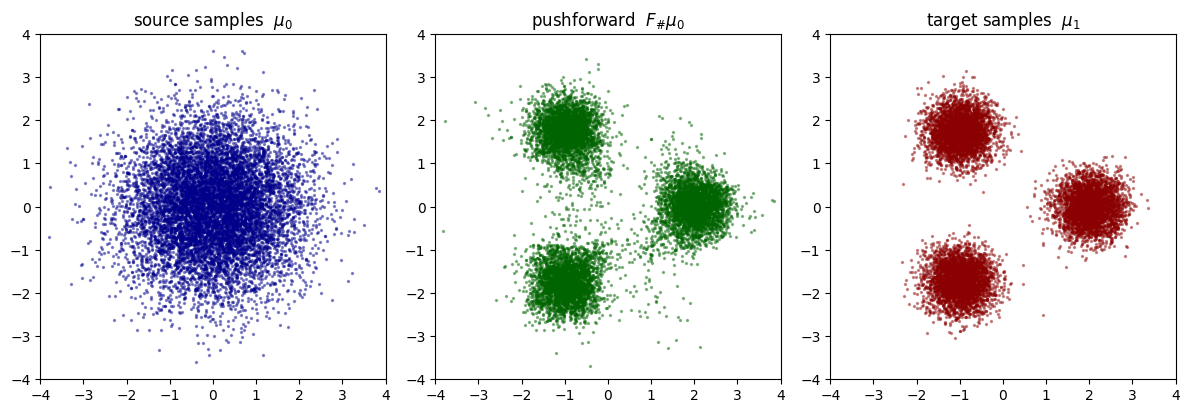

In [5]:
import matplotlib.pyplot as plt

with torch.no_grad():
    x_plot = u0.samples(N)                           # fresh samples from source
    y_pf, _ = flow.t().call_and_ladj(x_plot)         # pushforward F(x)
    y_true = u1.samples(N)                           # fresh samples from target (ground truth)

x_np = x_plot.cpu().numpy()
y_pf_np = y_pf.cpu().numpy()
y_true_np = y_true.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(x_np[:, 0], x_np[:, 1], s=2, alpha=0.4, color="darkblue")
axes[0].set_title(r"source samples  $\mu_0$")

axes[1].scatter(y_pf_np[:, 0], y_pf_np[:, 1], s=2, alpha=0.4, color="darkgreen")
axes[1].set_title(r"pushforward  $F_\# \mu_0$")

axes[2].scatter(y_true_np[:, 0], y_true_np[:, 1], s=2, alpha=0.4, color="darkred")
axes[2].set_title(r"target samples  $\mu_1$")

for ax in axes:
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Analysis of the result

The loss decreases monotonically from $\sim 1.7$ down to $\sim 0.4$, and the pushforward panel clearly recovers all three modes. A few qualitative observations:

- **Mode coverage.** Forward $\mathrm{KL}$ is *mass-covering* (zero-avoiding): $\mathrm{KL}(\mu_1 \,\|\, \nu)$ blows up on any region where $\mu_1 > 0$ but $\nu \to 0$. This biases the flow toward placing mass on every cluster of training data, so all three modes survive — no mode collapse, in contrast to what reverse $\mathrm{KL}$ can suffer from.
- **Mode width.** The pushforward modes are visibly *broader* than the ground-truth modes, and faint *bridges* connect them. This is the flip side of mass-covering: the flow extends mass into low-density gaps to keep $\nu$ strictly positive everywhere $\mu_1$ has support, even at the cost of putting mass where $\mu_1$ is essentially zero. With a continuous diffeomorphism $F$ acting on a connected base $\mu_0$, the pushforward $\nu$ is also connected, so it cannot exactly match a multi-modal target with disjoint support; the bridges are an unavoidable artifact of fitting a connected proposal to a disconnected target with forward $\mathrm{KL}$.
- **Implication.** If sharp modes matter (e.g.\ rare-event sampling), one would either train for longer / with more capacity, switch to reverse $\mathrm{KL}$ (energy-based, *mode-seeking*), or use a multi-modal base distribution to break the connectedness constraint.